# 23 -- N_b family at fixed gamma_* = 20: reconstructed spectra across N_b = 4..512

For each `N_b = 4, 8, 16, 32, 64, 128, 256, 512`, build `N_REALIZATIONS=16`
independent simultaneous-nucleation realizations all sized to the same
target `gamma_* = 20` (`box_size = R_*(gamma_*) * N_b^(1/3)`, same
`characteristic_scale`/`place_simultaneous_bubbles` convention as notebook
20 -- this is that notebook's sweep transposed: fix `gamma_*`, vary `N_b`
instead of the other way around). Since `gamma_*` is fixed, every case
shares the same `R_*` -- only the box size (and bubble count) grows.

Each realization's pairwise collision weights are computed locally with
`cpp/weights`, then reconstructed against the `gs1-20` production scan
(`19_production_scan.ipynb`), same as notebook 20.

Weights run locally, largest `N_b` first (cost scales roughly as `N_b^2`,
measured directly on this machine at `gamma_*=20`: 8->0.4s, 16->0.4s,
32->1.6s, 64->7.7s, 128->35.7s, 256->149.5s, 512->629.6s per realization) --
`8*16=128` jobs, overwhelmingly dominated by the `N_b=512` tier (~2.8h
serial on its own); `N_b=4` adds negligible cost. With the same 5-way local
parallelism as notebook 20 (`OMP_NUM_THREADS=2` x 5 concurrent workers on
this machine's 10 cores), wall time is roughly 45 min-1h.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from scipy.interpolate import interp1d

import ptbuilder as pt
from ptbuilder.analysis import load_scan, load_weights, write_weights_input
from ptbuilder.weight_scan_diagnostics import (
    characteristic_scale, load_kinematics, place_simultaneous_bubbles,
)

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

ROOT = Path(pt.__file__).parent.parent
DATA = ROOT / 'data'
PLOTS_DIR = ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

LAMBDA_BAR = 0.84
GAMMA_STAR = 20.0
N_B_LIST = [4, 8, 16, 32, 64, 128, 256, 512]
N_REALIZATIONS = 16              # independent realizations per N_b, median-combined
N_T = 1024                       # weights time resolution per case
MAX_T_OVER_RSTAR = 2.5           # weights time window, in units of R_*
BASE_SEED = 200020

NEW_SCAN_DIR = DATA / 'runtime_scan_lb0.84_gs1-20_kR1-100_nw32'
NEW_SCAN_KR_MIN, NEW_SCAN_KR_MAX = 1.0, 100.0   # KR_MIN/KR_MAX from 19_production_scan.ipynb

N_PLOT = 200   # points per reconstructed curve
X_PLOT = np.geomspace(NEW_SCAN_KR_MIN, NEW_SCAN_KR_MAX, N_PLOT)   # shared kR_* axis -- same for every case

lb_tag = f'{LAMBDA_BAR:g}'.replace('.', 'p')
CASE_ROOT = DATA / f'n_b_family_lb{lb_tag}_gstar{int(GAMMA_STAR)}_ens{N_REALIZATIONS}'

## 1. Build the 6 x 16 realizations (N_b = 8..256, gamma_* = 20 fixed) and run weights locally

Layout: `data/n_b_family_lb0p84_gstar20_ens16/n_b_{NNNN}/realization_{RR}/`.
Already-written cases are skipped, so a rerun only fills in anything
missing. Dispatched largest-`N_b`-first so the long `N_b=256` jobs don't
end up as an idle tail with nothing left to fill the other workers.

In [2]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

kin = load_kinematics(DATA / f'phi4_lambda_bar{LAMBDA_BAR:g}/instanton.h5')
_, R_STAR = characteristic_scale(kin, GAMMA_STAR)
print(f'gamma_*={GAMMA_STAR:g}: R_*={R_STAR:.4f}')

cases = []
for N_B in sorted(N_B_LIST, reverse=True):
    box_size = R_STAR * N_B ** (1.0 / 3.0)
    for realization in range(N_REALIZATIONS):
        case_dir = CASE_ROOT / f'n_b_{N_B:04d}' / f'realization_{realization:02d}'
        inp = case_dir / 'weights_input.h5'
        out = case_dir / 'weights_output.h5'
        if not inp.exists():
            case_dir.mkdir(parents=True, exist_ok=True)
            seed = int(BASE_SEED + N_B * 1_000_003 + realization * 100_000_003)
            positions = place_simultaneous_bubbles(
                N_B, box_size, seed, min_separation=2.0 * kin.profile.rmid_0)
            times = np.linspace(0.0, MAX_T_OVER_RSTAR * R_STAR, N_T)
            write_weights_input(inp, positions, times, kin, box_size, collision_radius='mid')
            with h5py.File(inp, 'a') as f:
                f.attrs['gamma_star'] = float(GAMMA_STAR)
                f.attrs['R_star'] = R_STAR
                f.attrs['N_b'] = N_B
                f.attrs['placement_seed'] = seed
                f.attrs['realization'] = realization
        cases.append((inp, out))

binary = ROOT / 'cpp/weights/weights'
env = os.environ.copy()
env['OMP_NUM_THREADS'] = '2'


def run_one(paths):
    inp, out = paths
    if not out.exists():
        subprocess.run([str(binary), str(inp), str(out)], check=True,
                       env=env, stdout=subprocess.DEVNULL)
    return out


with ThreadPoolExecutor(max_workers=5) as pool:
    futures = [pool.submit(run_one, paths) for paths in cases]
    for i, future in enumerate(as_completed(futures), 1):
        res = future.result()
        print(f'[{i:03d}/{len(futures)}] {res.parent.parent.name}/{res.parent.name}', flush=True)

gamma_*=20: R_*=277.4016
[001/128] n_b_0512/realization_05


[002/128] n_b_0512/realization_00


[003/128] n_b_0512/realization_07


[004/128] n_b_0512/realization_02


[005/128] n_b_0512/realization_06


...

[124/128] n_b_0004/realization_15


[125/128] n_b_0004/realization_11


[126/128] n_b_0004/realization_14


[127/128] n_b_0004/realization_12


[128/128] n_b_0004/realization_13


## 2. Load the gs1-20 production scan

In [3]:
from scipy.interpolate import RegularGridInterpolator

scan = load_scan(NEW_SCAN_DIR)
scan_gammas = np.array([r.gamma_ij for r in scan.rows])
scan_t_bounds = np.array([min(r.times[0] for r in scan.rows), scan.t_max])

N_T_COMMON = max(len(r.times) for r in scan.rows)
t_common = np.linspace(0.0, scan.t_max, N_T_COMMON)


def build_scan_interp(k_out):
    """(gamma_ij, t) -> spectrum interpolator projected onto k_out, backed by
    a single rectangular (gamma_ij, t_common, k_out) cube. Same construction
    as notebook 20."""
    Nk = len(k_out)

    spec_on_kout = []
    for r in scan.rows:
        spec_k = np.zeros((len(r.times), Nk))
        for it in range(len(r.times)):
            spec_k[it] = np.interp(k_out, r.wlist, r.spectrum[it], left=0., right=0.)
        spec_on_kout.append(spec_k)

    floor = max(s.max() for s in spec_on_kout) * 1e-12
    log_floor = np.log(floor)

    cube = np.empty((len(scan.rows), N_T_COMMON, Nk))
    for ir, (r, spec_k) in enumerate(zip(scan.rows, spec_on_kout)):
        log_spec = np.log(np.maximum(spec_k, floor))
        f = interp1d(r.times, log_spec, axis=0, kind='linear', bounds_error=False,
                     fill_value=(log_floor, log_spec[-1]))
        cube[ir] = f(t_common)

    rgi = RegularGridInterpolator((scan_gammas, t_common), cube,
                                  bounds_error=False, fill_value=log_floor)

    def interp_fn(pts):
        g_clip = np.clip(pts[:, 0], scan_gammas.min(), scan_gammas.max())
        query = np.column_stack([g_clip, pts[:, 1]])
        return np.exp(rgi(query))

    return interp_fn

Loaded scan runtime_scan_lb0.84_gs1-20_kR1-100_nw32: 124 rows, gamma_ij in [1.000, 50.000], T_MAX=416.102


## 3. Reconstruct each realization's spectrum, then the median per N_b

Same trimmed `bm_reconstruct` as notebook 20 (queries each pair's own
contiguous nonzero-weight window only -- exact, not an approximation, see
that notebook's Section 3 for the verification). Since `gamma_*` is fixed
here, `R_*` -- and therefore `k_plot = X_PLOT / R_*` and `interp_fn` -- is
the same for every `N_b` case, so both are built once outside the loop.

In [4]:
import time


def bm_reconstruct(gamma, weights_t, weights_times, t_max, interp_fn, times, gammas, Nk):
    """Same math as a full-range reconstruction, but only queries interp_fn
    over this pair's own contiguous nonzero-weight window (+1 trailing point
    for the diff) -- exact, see notebook 20's Section 3."""
    g = float(np.clip(gamma, gammas.min(), gammas.max()))
    t_hi = min(t_max, times[-1])

    nz = np.where(weights_t > 0)[0]
    if len(nz) == 0:
        return np.zeros(Nk)
    lo, hi = nz[0], min(nz[-1] + 2, len(weights_times))
    t_window = weights_times[lo:hi]
    w_window = weights_t[lo:hi]

    mask = (t_window >= times[0]) & (t_window <= t_hi)
    t_comp = t_window[mask]
    w_comp = w_window[mask]
    if len(t_comp) == 0 or t_comp[-1] < t_hi:
        t_comp = np.append(t_comp, t_hi)
        w_comp = np.append(w_comp, np.interp(t_hi, weights_times, weights_t))
    if len(t_comp) < 2:
        return np.zeros(Nk)

    pts = np.column_stack([np.full(len(t_comp), g), t_comp])
    specs = interp_fn(pts)
    delta = np.diff(specs, axis=0)
    return (w_comp[:len(t_comp) - 1, None] * delta).sum(axis=0)


t_start = time.time()

k_plot = X_PLOT / R_STAR   # same for every N_b case -- gamma_* is fixed
interp_fn = build_scan_interp(k_plot)

ensembles = {}
reconstructions_median = {}
case_meta = {}
for N_B in N_B_LIST:
    ndir = CASE_ROOT / f'n_b_{N_B:04d}'

    spectra = np.zeros((N_REALIZATIONS, N_PLOT))
    n_pairs_list = []
    L_box = None
    for realization in range(N_REALIZATIONS):
        rdir = ndir / f'realization_{realization:02d}'
        with h5py.File(rdir / 'weights_input.h5', 'r') as f:
            L_box = float(f.attrs['L'])
            weights_times = f['t'][:]
        weights, pair_i, pair_j, pair_gammas = load_weights(rdir / 'weights_output.h5', N_T)

        spectrum = np.zeros(N_PLOT)
        for w_row, g in zip(weights, pair_gammas):
            spectrum += bm_reconstruct(float(g), w_row, weights_times, weights_times[-1],
                                       interp_fn, scan_t_bounds, scan_gammas, N_PLOT)
        spectra[realization] = spectrum
        n_pairs_list.append(len(pair_i))

    ensembles[N_B] = spectra
    reconstructions_median[N_B] = np.median(spectra, axis=0)
    case_meta[N_B] = dict(R_star=R_STAR, L_box=L_box)
    print(f'N_b={N_B:4d}: L={L_box:.2f}, {N_REALIZATIONS} realizations, '
          f'pairs {min(n_pairs_list)}-{max(n_pairs_list)}')

print(f'\nSection 3 wall time: {time.time() - t_start:.1f}s')

N_b=   4: L=440.35, 16 realizations, pairs 5-6


N_b=   8: L=554.80, 16 realizations, pairs 23-28


N_b=  16: L=699.01, 16 realizations, pairs 76-91


N_b=  32: L=880.70, 16 realizations, pairs 217-237


N_b=  64: L=1109.61, 16 realizations, pairs 477-508


N_b= 128: L=1398.02, 16 realizations, pairs 975-1004


N_b= 256: L=1761.39, 16 realizations, pairs 1964-2035


N_b= 512: L=2219.21, 16 realizations, pairs 3942-3994

Section 3 wall time: 34.9s


## 4. Convert to CHW units and plot the N_b family (median of 16)

Each curve's median spectrum was reconstructed directly on `k_plot = X_PLOT
/ R_*` (shared across every case, since `gamma_*` is fixed), so
`energy_to_chw`'s `x` output is `X_PLOT` again for every case, exactly --
no masking needed. Curves are colored by `N_b` (log-scale colorbar, since
`N_b` spans a factor of 32).

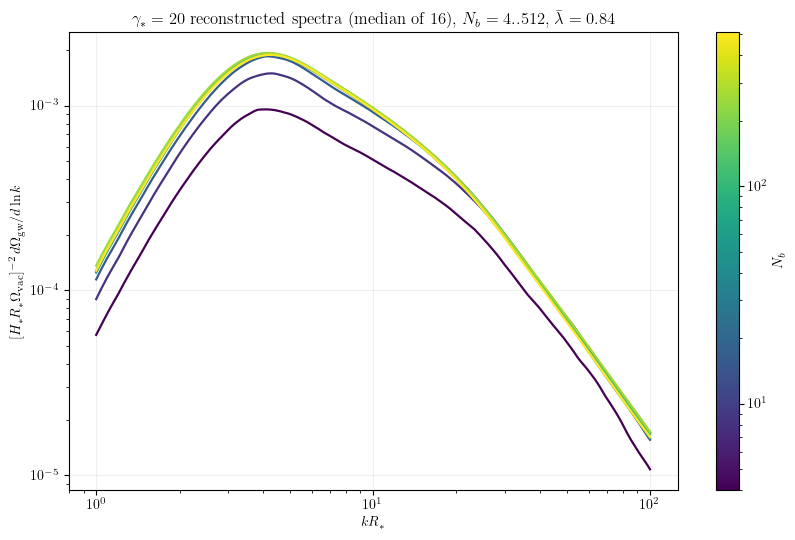

In [5]:
def rho_vac_bar(lambda_bar):
    """False-minus-true vacuum energy in BM dimensionless units."""
    U = 3.0 + np.sqrt(9.0 - 8.0 * lambda_bar)
    V_true = 0.5 - U / (4.0 * lambda_bar) + U**2 / (32.0 * lambda_bar)
    return -V_true


def energy_to_chw(k, dE_dlnk, Rstar, lambda_bar, volume):
    rho_vac = rho_vac_bar(lambda_bar)
    x = np.asarray(k) * Rstar
    y = (3.0 / (8.0 * np.pi * rho_vac**2 * Rstar**2 * volume)) * np.asarray(dE_dlnk)
    return x, y


norm = LogNorm(vmin=min(N_B_LIST), vmax=max(N_B_LIST))
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for N_B in N_B_LIST:
    meta = case_meta[N_B]
    x, y = energy_to_chw(k_plot, reconstructions_median[N_B],
                         meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    ax.plot(x, y, color=cmap(norm(N_B)), lw=1.6, label=rf'$N_b={N_B}$')

colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax)
colorbar.set_label(r'$N_b$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$kR_*$')
ax.set_ylabel(r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$')
ax.set_title(rf'$\gamma_*={GAMMA_STAR:g}$ reconstructed spectra (median of {N_REALIZATIONS}), '
            rf'$N_b={N_B_LIST[0]}..{N_B_LIST[-1]}$, $\bar{{\lambda}}={LAMBDA_BAR}$')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'n_b_family_gstar20.pdf', bbox_inches='tight')
plt.show()

## 5. Peak amplitude vs N_b

Peak of the median-of-16 curve at each `N_b`, plus the spread of the 16
individual realizations' own peaks (shaded band = min-max), to see whether
the peak amplitude is converging as `N_b` grows.

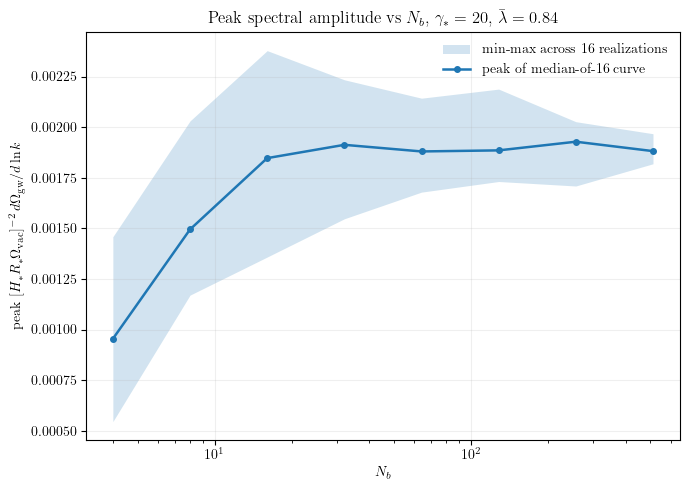

In [6]:
peak_median = np.zeros(len(N_B_LIST))
peak_min = np.zeros(len(N_B_LIST))
peak_max = np.zeros(len(N_B_LIST))

for i_n, N_B in enumerate(N_B_LIST):
    meta = case_meta[N_B]

    _, y_median = energy_to_chw(k_plot, reconstructions_median[N_B],
                                meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    peak_median[i_n] = y_median.max()

    peaks_per_realization = np.array([
        energy_to_chw(k_plot, spec, meta['R_star'], LAMBDA_BAR, meta['L_box']**3)[1].max()
        for spec in ensembles[N_B]
    ])
    peak_min[i_n] = peaks_per_realization.min()
    peak_max[i_n] = peaks_per_realization.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(N_B_LIST, peak_min, peak_max, color='C0', alpha=0.2, linewidth=0,
                label='min-max across 16 realizations')
ax.plot(N_B_LIST, peak_median, 'o-', color='C0', lw=1.8, ms=4,
        label='peak of median-of-16 curve')
ax.set_xscale('log')
ax.set_xlabel(r'$N_b$')
ax.set_ylabel(r'peak $[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$')
ax.set_title(rf'Peak spectral amplitude vs $N_b$, $\gamma_*={GAMMA_STAR:g}$, $\bar{{\lambda}}={LAMBDA_BAR}$')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'n_b_family_gstar20_peak_convergence.pdf', bbox_inches='tight')
plt.show()

## 6. Combined single-column figure

Both plots above, stacked into one single-column (2-row) figure for the
paper: the spectra family on top, peak convergence below, sharing one
`N_b` colorbar so the two panels read as one figure rather than two
independent ones -- the peak-convergence markers are colored the same way
as the spectra curves above them.

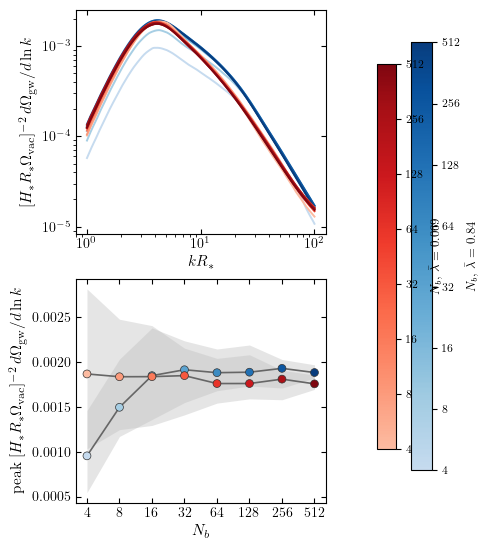

In [7]:
import pickle
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator


def truncate_colormap(cmap, minval=0.25, maxval=0.95, n=256):
    """A single-hue sequential colormap (e.g. 'Blues') run through its full
    range includes near-white at the low end -- truncating it keeps every
    curve visible while staying a calm, single-hue gradient rather than
    viridis's full-spectrum look."""
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))


# lambda_bar=0.069 N_b-family at the same gamma_*=20 (its own R_*, since
# R_* depends on lambda_bar too), built by an identical standalone script --
# overlaid here (in Reds) on the same axes as the lambda_bar=0.84 family
# (Blues) above, so the two families' peak amplitudes can be compared
# directly.
with open(DATA / 'n_b_family_lb0p069_gstar20_ens16_reconstructed.pkl', 'rb') as f:
    d069 = pickle.load(f)
N_B_LIST_069 = d069['N_B_LIST']
X_PLOT_069 = d069['X_PLOT']
LAMBDA_BAR_069 = d069['LAMBDA_BAR']
R_STAR_069 = d069['R_STAR']
ensembles_069 = d069['ensembles']
reconstructions_median_069 = d069['reconstructions_median']
case_meta_069 = d069['case_meta']
k_plot_069 = X_PLOT_069 / R_STAR_069

peak_median_069 = np.zeros(len(N_B_LIST_069))
peak_min_069 = np.zeros(len(N_B_LIST_069))
peak_max_069 = np.zeros(len(N_B_LIST_069))
for i_n, N_B in enumerate(N_B_LIST_069):
    meta = case_meta_069[N_B]
    _, y_median = energy_to_chw(k_plot_069, reconstructions_median_069[N_B],
                                meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)
    peak_median_069[i_n] = y_median.max()
    peaks_per_realization = np.array([
        energy_to_chw(k_plot_069, spec, meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)[1].max()
        for spec in ensembles_069[N_B]
    ])
    peak_min_069[i_n] = peaks_per_realization.min()
    peak_max_069[i_n] = peaks_per_realization.max()


norm = LogNorm(vmin=min(N_B_LIST), vmax=max(N_B_LIST))
norm_069 = LogNorm(vmin=min(N_B_LIST_069), vmax=max(N_B_LIST_069))
cmap = truncate_colormap(plt.get_cmap('Blues'))
cmap_069 = truncate_colormap(plt.get_cmap('Reds'))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4.6, 6.4))

# --- Top: spectra family -----------------------------------------------
for N_B in N_B_LIST:
    meta = case_meta[N_B]
    x, y = energy_to_chw(k_plot, reconstructions_median[N_B],
                         meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    ax_top.plot(x, y, color=cmap(norm(N_B)), lw=1.4)

for N_B in N_B_LIST_069:
    meta = case_meta_069[N_B]
    x, y = energy_to_chw(k_plot_069, reconstructions_median_069[N_B],
                         meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)
    ax_top.plot(x, y, color=cmap_069(norm_069(N_B)), lw=1.4)

ax_top.set_xscale('log')
ax_top.set_yscale('log')
ax_top.set_xlabel(r'$kR_*$', fontsize=11)
ax_top.set_ylabel(r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$', fontsize=11)
ax_top.tick_params(axis='both', labelsize=10, top=True, right=True, direction='in')

# --- Bottom: peak convergence, colored the same way as the spectra -----
ax_bot.fill_between(N_B_LIST, peak_min, peak_max, color='0.75', alpha=0.4, linewidth=0)
ax_bot.plot(N_B_LIST, peak_median, '-', color='0.4', lw=1.2, zorder=2)
ax_bot.scatter(N_B_LIST, peak_median, c=N_B_LIST, cmap=cmap, norm=norm,
              s=32, zorder=3, edgecolor='0.2', linewidth=0.5)

ax_bot.fill_between(N_B_LIST_069, peak_min_069, peak_max_069, color='0.75', alpha=0.4, linewidth=0)
ax_bot.plot(N_B_LIST_069, peak_median_069, '-', color='0.4', lw=1.2, zorder=2)
ax_bot.scatter(N_B_LIST_069, peak_median_069, c=N_B_LIST_069, cmap=cmap_069, norm=norm_069,
              s=32, zorder=3, edgecolor='0.2', linewidth=0.5)

ax_bot.set_xscale('log')
ax_bot.set_xlabel(r'$N_b$', fontsize=11)
ax_bot.set_ylabel(r'peak $[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$', fontsize=11)
ax_bot.xaxis.set_major_locator(FixedLocator(N_B_LIST))
ax_bot.xaxis.set_major_formatter(FixedFormatter([str(n) for n in N_B_LIST]))
ax_bot.xaxis.set_minor_locator(NullLocator())
ax_bot.tick_params(axis='both', labelsize=10, top=True, right=True, direction='in')

cb1 = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=[ax_top, ax_bot],
                   fraction=0.06, pad=0.04)
cb1.set_ticks(N_B_LIST)
cb1.set_ticklabels([str(n) for n in N_B_LIST])
cb1.ax.yaxis.set_minor_locator(NullLocator())
cb1.set_label(r'$N_b$, $\bar\lambda=0.84$', fontsize=9)
cb1.ax.tick_params(labelsize=8)

cb2 = fig.colorbar(ScalarMappable(norm=norm_069, cmap=cmap_069), ax=[ax_top, ax_bot],
                   fraction=0.06, pad=0.16)
cb2.set_ticks(N_B_LIST_069)
cb2.set_ticklabels([str(n) for n in N_B_LIST_069])
cb2.ax.yaxis.set_minor_locator(NullLocator())
cb2.set_label(r'$N_b$, $\bar\lambda=0.069$', fontsize=9)
cb2.ax.tick_params(labelsize=8)

fig.savefig(PLOTS_DIR / 'n_b_family_gstar20_combined.pdf', bbox_inches='tight')
plt.show()